In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multitest import fdrcorrection_twostage

import warnings
warnings.filterwarnings("ignore")

In [42]:
cd C:\Users\tr432\Downloads\Figures_GutLungAxis\no0

C:\Users\tr432\Downloads\Figures_GutLungAxis\no0


In [47]:
## 리눅스 lefse 환경의 run_lefse.py 단계에서 -a 1.0 / -w 1.0 / -l 0 으로 설정한 후 나온 파일 (모든 features의 p-value가 나와있는 파일)을 넣어야함
# -> 그래야 fdr correction 가능
df = pd.read_csv('picrust2_con-vnam_raw.res', sep='\t', header=None)

df.rename(columns={df.columns[0]: "Features"}, inplace=True)
df.rename(columns={df.columns[1]: "LD1"}, inplace=True)
df.rename(columns={df.columns[2]: "Group"}, inplace=True)
df.rename(columns={df.columns[3]: "LD2"}, inplace=True)
df.rename(columns={df.columns[4]: "p-val"}, inplace=True)

df.head(5)

,Features,LD1,Group,LD2,p-val
0,Phenylalaninemetabolism,3.810730,VNAM,3.311218,2.598475e-07
1,Toxoplasmosis,0.715001,Control,0.598540,4.284543e-05
2,Ribosome,4.211000,Control,3.493666,4.941866e-07
3,Planthormonesignaltransduction,0.000000,VNAM,2.471835,9.380234e-01
4,D_Alaninemetabolism,4.287307,Control,2.985686,1.353511e-01


In [51]:
## (선택1) FDR (Benjamini-Hochberg)

df["p-val"] = pd.to_numeric(df["p-val"], errors="coerce")

# BH-FDR (q-value) 계산
rej, qvals, _, _ = multipletests(df["p-val"].values, alpha=0.05, method="fdr_bh")
df["q-val"] = qvals

print(df[["p-val", "q-val"]])
print(df[df["p-val"] < 0.05].shape[0])
print(df[df["q-val"] < 0.05].shape[0])

            p-val     q-val
0    2.598475e-07  0.000002
1    4.284543e-05  0.000088
2    4.941866e-07  0.000003
3    9.380234e-01  0.943923
4    1.353511e-01  0.177510
..            ...       ...
155  3.047947e-02  0.045577
156  1.730238e-05  0.000037
157  3.118706e-06  0.000008
158  6.778520e-07  0.000004
159  2.207744e-07  0.000002

[160 rows x 2 columns]
109
107


In [52]:
## (선택2) FDR (BKY)

rej, qvals, _, _ = fdrcorrection_twostage(df["p-val"].values, alpha=0.05, method="bky")  ## BKY(2006) two-stage linear step-up
df["q-val"] = qvals

print(df[["p-val", "q-val"]])
print(df[df["p-val"] < 0.05].shape[0])
print(df[df["q-val"] < 0.05].shape[0])

            p-val         q-val
0    2.598475e-07  6.885959e-07
1    4.284543e-05  3.056856e-05
2    4.941866e-07  1.100059e-06
3    9.380234e-01  3.283082e-01
4    1.353511e-01  6.174009e-02
..            ...           ...
155  3.047947e-02  1.585217e-02
156  1.730238e-05  1.283837e-05
157  3.118706e-06  2.629636e-06
158  6.778520e-07  1.397128e-06
159  2.207744e-07  6.885959e-07

[160 rows x 2 columns]
109
118


In [53]:
df_raw = df.copy()

#df_ld2.set_index('Genus', inplace=True)
df_raw.loc[df_raw['Group'] == 'Control', 'LD2'] *= -1  #Edit: LD2 값을 음수로 설정할 그룹명 입력

df_raw

,Features,LD1,Group,LD2,p-val,q-val
0,Phenylalaninemetabolism,3.810730,VNAM,3.311218,2.598475e-07,6.885959e-07
1,Toxoplasmosis,0.715001,Control,-0.598540,4.284543e-05,3.056856e-05
2,Ribosome,4.211000,Control,-3.493666,4.941866e-07,1.100059e-06
3,Planthormonesignaltransduction,0.000000,VNAM,2.471835,9.380234e-01,3.283082e-01
4,D_Alaninemetabolism,4.287307,Control,-2.985686,1.353511e-01,6.174009e-02
...,...,...,...,...,...,...
155,Methanemetabolism,3.700225,Control,-1.759503,3.047947e-02,1.585217e-02
156,DNAreplication,4.107143,Control,-3.226657,1.730238e-05,1.283837e-05
157,N_Glycanbiosynthesis,2.746131,Control,-2.319572,3.118706e-06,2.629636e-06
158,Amoebiasis,2.363630,VNAM,1.885562,6.778520e-07,1.397128e-06


In [54]:
df_ld3 = df_raw[(abs(df_raw['LD2']) >= 3) & (df_raw['q-val'] < 0.05)].copy()
#df_ld3.set_index('Genus', inplace=True)
print(df_ld3.head(3))
print(df_ld3.shape[0])

                     Features       LD1    Group       LD2         p-val  \
0     Phenylalaninemetabolism  3.810730     VNAM  3.311218  2.598475e-07   
2                    Ribosome  4.211000  Control -3.493666  4.941866e-07   
6  Aminoacyl_tRNAbiosynthesis  4.230601  Control -3.356840  4.844424e-06   

          q-val  
0  6.885959e-07  
2  1.100059e-06  
6  3.851317e-06  
58


In [55]:
df_ld3 = df_ld3.sort_values(by='LD2')

#df_ld3.to_csv('df_ld3_qval.05_GutLungAxis.csv', index=False)
df_ld3

,Features,LD1,Group,LD2,p-val,q-val
54,Otherglycandegradation,4.377846,Control,-3.877196,3.118706e-06,2.629636e-06
48,Secondarybileacidbiosynthesis,4.267632,Control,-3.654344,1.235884e-03,7.239680e-04
120,D_GlutamineandD_glutamatemetabolism,4.333543,Control,-3.597391,1.081623e-06,1.672008e-06
2,Ribosome,4.211000,Control,-3.493666,4.941866e-07,1.100059e-06
110,RNApolymerase,4.032258,Control,-3.465548,2.207744e-07,6.885959e-07
159,Onecarbonpoolbyfolate,4.252655,Control,-3.443758,2.207744e-07,6.885959e-07
103,Alanine_aspartateandglutamatemetabolism,4.264218,Control,-3.423935,3.118706e-06,2.629636e-06
86,Cellcycle_Caulobacter,4.192316,Control,-3.418387,3.118706e-06,2.629636e-06
92,Terpenoidbackbonebiosynthesis,4.141372,Control,-3.399762,2.207744e-07,6.885959e-07
6,Aminoacyl_tRNAbiosynthesis,4.230601,Control,-3.356840,4.844424e-06,3.851317e-06


In [56]:
df_ld3.shape

(58, 6)

In [57]:
%matplotlib inline

In [58]:
Before = df_ld3[df_ld3['LD2'] < 0]
After = df_ld3[df_ld3['LD2'] > 0]

print(Before.shape)
print(After.shape)

(27, 6)
(31, 6)


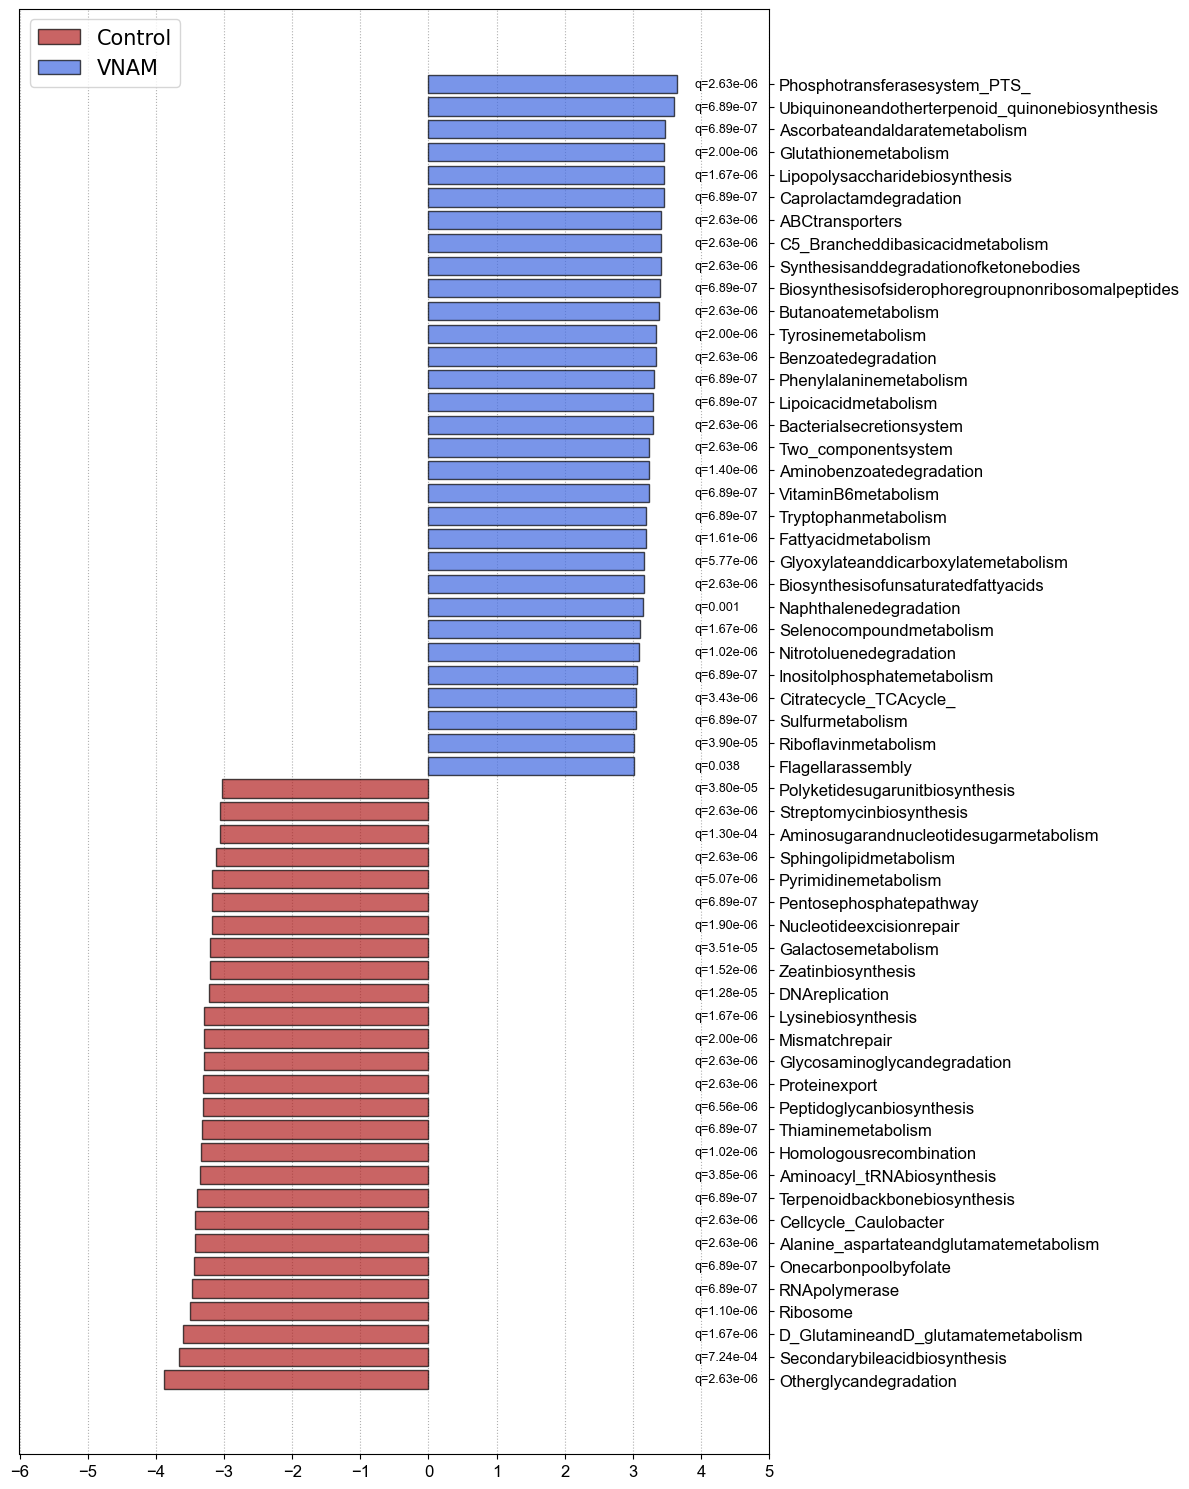

In [66]:
plt.figure(figsize=(12, 15))  #Edit

# Effect Size를 float로 변환
float_Before = Before['LD2'].astype(float).tolist()
float_After = After['LD2'].astype(float).tolist()

# x축 범위 설정
Mini = math.floor(min(float_Before))
Maxi = math.ceil(max(float_After))

x_range = list(range(Mini-10, Maxi+10, 1))  # xticks 간격 조절
plt.xticks(x_range, fontsize=12, fontname='Arial')

# 양수와 음수 데이터 분리
negative_effects = df_ld3[df_ld3['LD2'] < 0]  #Edit: masking 안된 데이터 쓰려면 이 부분 변경
positive_effects = df_ld3[df_ld3['LD2'] > 0]  #Edit: masking 안된 데이터 쓰려면 이 부분 변경

y_pos_negative = np.arange(len(Before))
y_pos_positive = len(Before) + np.arange(len(After))

bars_negative = plt.barh(y_pos_negative, Before['LD2'], color='firebrick', alpha=0.7, edgecolor='k', label='Control', zorder=3)  #Edit
bars_positive = plt.barh(y_pos_positive, After['LD2'], color='royalblue', alpha=0.7, edgecolor='k', label='VNAM', zorder=3)  #Edit
## LDA plot default color: negative-'r' / positive-'g'



# 눈금선을 점선으로 설정, 막대 그래프 뒤로 보내기
plt.grid(True, axis='x', linestyle='dotted', zorder=0)
        
# y축에 카테고리 이름 표시
plt.yticks(np.concatenate([y_pos_negative, y_pos_positive]), 
           np.concatenate([negative_effects['Features'], positive_effects['Features']]),
           fontsize=12,
           fontname='Arial')


# q-value를 조건부로 표시
df_ld3['q-val'] = pd.to_numeric(df_ld3['q-val'], errors='coerce')
for i, q_val in enumerate(df_ld3['q-val']):
    if q_val < 0.001:
        q_val_str = f'{q_val:.2e}'  # 지수 표기법
    else:
        q_val_str = f'{q_val:.3f}'  # 일반 표기법

    plt.text(
        3.9,  #Edit: x축 위치를 그래프의 오른쪽 바깥쪽으로 설정 (5로 이동)
        i, 
        f'q={q_val_str}',  # 조건부로 p-value 표시
        va='center', ha='left', color='k', fontsize=9, fontname='Arial',
        transform=plt.gca().transData
    )    

plt.xlim(-6, 5)
plt.xlabel('', fontsize=14, fontname='Arial')
plt.ylabel('')
ax = plt.gca()
ax.yaxis.set_ticks_position('right')
plt.title('', fontsize=12)
#plt.legend(bbox_to_anchor=(1.01, 1.01), fontsize=8.5, edgecolor='grey')

plt.tight_layout()

plt.legend(fontsize=15, loc='best')  #Edit

#plt.savefig("lda.pdf", dpi=500, format='pdf', bbox_inches='tight')
plt.savefig("picrust2_lda_fdr_BKY.png", dpi=500, bbox_inches='tight')

plt.show()